 # OpenFire EDA — Notebook 1: California Fire History



 **Purpose:** Load the Cal Fire FRAP historical fire perimeters dataset,

 explore data quality and patterns, build an interactive exploration map,

 and produce a polished animation of California's fire history.



 **Sections:**

 - A: Data Acquisition & Loading

 - B: Data Quality & Basic EDA

 - C: Interactive Exploration App (Panel + pydeck) — *coming next*

 - D: Polished Video Export (matplotlib → mp4) — *coming next*



 **Data source:** CAL FIRE FRAP firep24_1 (released April 2025)

 https://www.fire.ca.gov/what-we-do/fire-resource-assessment-program/fire-perimeters

 =============================================================================

 SECTION A — Data Acquisition & Loading

 =============================================================================

In [30]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import contextily as cx
from pathlib import Path
from zipfile import ZipFile
from tqdm import tqdm
import requests
import warnings
import sys
import os

# Add parent dir to path so we can import config
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from config import *

warnings.filterwarnings("ignore", category=FutureWarning)

print(f"Data directory:   {DATA_DIR.resolve()}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")
print(f"Raster resolution: {RASTER_RESOLUTION_M}m")


Data directory:   /Users/tomas/Documents/02d-USF-MSDS/MSDS603/openfire/data
Output directory: /Users/tomas/Documents/02d-USF-MSDS/MSDS603/openfire/outputs/eda
Raster resolution: 1000m


In [31]:
import fiona

if not FIRE_PERIMETERS_GDB.exists():
    if FIRE_PERIMETERS_ZIP.exists():
        print(f"Extracting {FIRE_PERIMETERS_ZIP.name}...")
        with ZipFile(FIRE_PERIMETERS_ZIP, "r") as zf:
            zf.extractall(RAW_DIR)
        # Find the .gdb folder that was extracted
        gdb_folders = list(RAW_DIR.glob("*.gdb"))
        print(f"✓ Extracted {len(gdb_folders)} geodatabase(s):")
        for g in gdb_folders:
            print(f"   {g.name}")
    else:
        raise FileNotFoundError(
            f"Fire perimeters zip not found at: {FIRE_PERIMETERS_ZIP.resolve()}\n"
            f"Download from: https://frap.fire.ca.gov/mapping/gis-data/\n"
            f"Save as: {FIRE_PERIMETERS_ZIP.resolve()}"
        )
else:
    print(f"✓ Geodatabase already extracted: {FIRE_PERIMETERS_GDB.name}")


✓ Geodatabase already extracted: fire24_1.gdb


In [32]:
# A .gdb can contain multiple layers (fire perimeters, prescribed burns, etc.)
# Let's see what's inside.

# If the exact .gdb path from config doesn't exist, find it
gdb_path = FIRE_PERIMETERS_GDB
if not gdb_path.exists():
    gdb_folders = list(RAW_DIR.glob("*.gdb"))
    if gdb_folders:
        gdb_path = gdb_folders[0]
        print(f"⚠️  Expected {FIRE_PERIMETERS_GDB.name}, found {gdb_path.name}")
        print(f"   Update FIRE_PERIMETERS_GDB in config.py if needed.")
    else:
        raise FileNotFoundError("No .gdb folder found in data/raw/")

layers = fiona.listlayers(gdb_path)
print(f"Geodatabase: {gdb_path.name}")
print(f"Layers ({len(layers)}):")
for layer in layers:
    with fiona.open(gdb_path, layer=layer) as src:
        print(f"  {layer:<30} {len(src):>6,} features  |  {src.schema['geometry']}")

# Pick the fire perimeters layer (firep*), not prescribed burns (rxburn*)
fire_layer = FIRE_PERIMETERS_LAYER
if fire_layer not in layers:
    # Auto-detect: look for a layer with "firep" in the name
    for layer in layers:
        if "firep" in layer.lower():
            fire_layer = layer
            break
    else:
        fire_layer = layers[0]  # fallback to first layer
    print(f"\n⚠️  Layer '{FIRE_PERIMETERS_LAYER}' not found, using '{fire_layer}'")
else:
    print(f"\n→ Using layer: {fire_layer}")


Geodatabase: fire24_1.gdb
Layers (2):
  rxburn24_1                     10,675 features  |  MultiPolygon
  firep24_1                      22,810 features  |  MultiPolygon

→ Using layer: firep24_1


In [33]:
print(f"Loading layer '{fire_layer}' from {gdb_path.name}...")
gdf_raw = gpd.read_file(gdb_path, layer=fire_layer)

print(f"\n{'='*60}")
print(f"FRAP Fire Perimeters — Initial Load")
print(f"{'='*60}")
print(f"Records:    {len(gdf_raw):,}")
print(f"Columns:    {len(gdf_raw.columns)}")
print(f"CRS:        {gdf_raw.crs}")
print(f"Bounds:     {gdf_raw.total_bounds}")
print(f"Memory:     {gdf_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nColumn names:\n{list(gdf_raw.columns)}")


Loading layer 'firep24_1' from fire24_1.gdb...

FRAP Fire Perimeters — Initial Load
Records:    22,810
Columns:    20
CRS:        EPSG:3310
Bounds:     [-373237.5436 -604727.5643  539438.201   518283.7376]
Memory:     13.2 MB

Column names:
['YEAR_', 'STATE', 'AGENCY', 'UNIT_ID', 'FIRE_NAME', 'INC_NUM', 'IRWINID', 'ALARM_DATE', 'CONT_DATE', 'C_METHOD', 'CAUSE', 'COMPLEX_NAME', 'COMPLEX_ID', 'OBJECTIVE', 'GIS_ACRES', 'COMMENTS', 'FIRE_NUM', 'Shape_Length', 'Shape_Area', 'geometry']


In [34]:
print("Data types:")
print(gdf_raw.dtypes.to_string())
print(f"\nFirst 5 rows (non-geometry columns):")
gdf_raw.drop(columns="geometry").head()


Data types:
YEAR_                       float64
STATE                           str
AGENCY                          str
UNIT_ID                         str
FIRE_NAME                       str
INC_NUM                         str
IRWINID                         str
ALARM_DATE      datetime64[ms, UTC]
CONT_DATE       datetime64[ms, UTC]
C_METHOD                    float64
CAUSE                         int16
COMPLEX_NAME                    str
COMPLEX_ID                      str
OBJECTIVE                   float64
GIS_ACRES                   float32
COMMENTS                        str
FIRE_NUM                        str
Shape_Length                float64
Shape_Area                  float64
geometry                   geometry

First 5 rows (non-geometry columns):


,YEAR_,STATE,AGENCY,UNIT_ID,FIRE_NAME,INC_NUM,IRWINID,ALARM_DATE,CONT_DATE,C_METHOD,CAUSE,COMPLEX_NAME,COMPLEX_ID,OBJECTIVE,GIS_ACRES,COMMENTS,FIRE_NUM,Shape_Length,Shape_Area
0,2025.0,CA,CDF,LDF,PALISADES,00000738,{A7EA5D21-F882-44B8-BF64-44AB11059DC1},2025-01-07 00:00:00+00:00,2025-01-31 00:00:00+00:00,7.0,14,NaN,NaN,1.0,23448.882812,NaN,NaN,116028.197349,9.489426e+07
1,2025.0,CA,CDF,LAC,EATON,00009087,{72660ADC-B5EF-4D96-A33F-B4EA3740A4E3},2025-01-08 00:00:00+00:00,2025-01-31 00:00:00+00:00,7.0,14,NaN,NaN,1.0,14056.260742,NaN,NaN,86677.545056,5.688367e+07
2,2025.0,CA,CDF,ANF,HUGHES,00250270,{994072D2-E154-434A-BB95-6F6C94C40829},2025-01-22 00:00:00+00:00,2025-01-28 00:00:00+00:00,7.0,14,NaN,NaN,1.0,10396.798828,NaN,NaN,79554.126153,4.207435e+07
3,2025.0,CA,CCO,VNC,KENNETH,00003155,{842FB37B-7AC8-4700-BB9C-028BF753D149},2025-01-09 00:00:00+00:00,2025-02-04 00:00:00+00:00,2.0,14,NaN,NaN,1.0,998.737793,from OES Intel 24,NaN,12891.056545,4.041748e+06
4,2025.0,CA,CDF,LDF,HURST,00003294,{F4E810AD-CDF3-4ED4-B63F-03D43785BA7B},2025-01-07 00:00:00+00:00,2025-01-09 00:00:00+00:00,7.0,14,NaN,NaN,1.0,831.385498,NaN,NaN,13274.108148,3.364498e+06


In [35]:
# We need two versions:
#   - EPSG:3310 (CA Albers Equal Area) for area calculations, rasterization, static maps
#   - EPSG:4326 (WGS84 lat/lon) for web maps, pydeck, Folium

print(f"Original CRS: {gdf_raw.crs}")

# Reproject to CA Albers for area-preserving analysis
gdf = gdf_raw.to_crs(CRS_CA_ALBERS)
print(f"Reprojected to: {gdf.crs}  (California Albers Equal Area)")
print(f"New bounds: {gdf.total_bounds}")


# =============================================================================
# SECTION B — Data Quality & Basic EDA
# =============================================================================


Original CRS: EPSG:3310
Reprojected to: EPSG:3310  (California Albers Equal Area)
New bounds: [-373237.5436 -604727.5643  539438.201   518283.7376]


In [36]:
# FRAP column names can vary between releases. Let's check what we have
# and standardize the key fields we need.

# Print all columns with sample values to understand what we're working with
print("Column inventory:")
print("-" * 70)
for col in gdf.columns:
    if col == "geometry":
        continue
    non_null = gdf[col].dropna()
    n_null = gdf[col].isna().sum()
    sample = non_null.iloc[0] if len(non_null) > 0 else "ALL NULL"
    print(f"  {col:<20} nulls={n_null:>5}  sample: {sample}")


Column inventory:
----------------------------------------------------------------------
  YEAR_                nulls=   77  sample: 2025.0
  STATE                nulls=    0  sample: CA
  AGENCY               nulls=   49  sample: CDF
  UNIT_ID              nulls=   61  sample: LDF
  FIRE_NAME            nulls=   62  sample: PALISADES
  INC_NUM              nulls=  971  sample: 00000738
  IRWINID              nulls=19074  sample: {A7EA5D21-F882-44B8-BF64-44AB11059DC1}
  ALARM_DATE           nulls= 5396  sample: 2025-01-07 00:00:00+00:00
  CONT_DATE            nulls=12630  sample: 2025-01-31 00:00:00+00:00
  C_METHOD             nulls=12102  sample: 7.0
  CAUSE                nulls=    0  sample: 14
  COMPLEX_NAME         nulls=22199  sample: FRESNO JUNE LIGHTNING COMPLEX
  COMPLEX_ID           nulls=22243  sample: AFC5730E-2C3A-464B-8BCE-3967545980D3
  OBJECTIVE            nulls=  271  sample: 1.0
  GIS_ACRES            nulls=    0  sample: 23448.8828125
  COMMENTS             nulls=19

In [37]:
# Key fields we expect:
#   YEAR_ — fire year (integer, should always be present)
#   ALARM_DATE — date fire was reported (datetime, often NULL for old fires)
#   CONT_DATE — date fire was contained (datetime, often NULL)
#   FIRE_NAME — name of the fire
#   GIS_ACRES — acreage from GIS polygon measurement
#   CAUSE — fire cause code

# Ensure YEAR_ is integer
if "YEAR_" in gdf.columns:
    gdf["year"] = pd.to_numeric(gdf["YEAR_"], errors="coerce").astype("Int64")
elif "YEAR" in gdf.columns:
    gdf["year"] = pd.to_numeric(gdf["YEAR"], errors="coerce").astype("Int64")
else:
    print("⚠️  No YEAR column found! Available columns:", list(gdf.columns))

# Parse ALARM_DATE
date_col = None
for candidate in ["ALARM_DATE", "ALARMDATE", "alarm_date"]:
    if candidate in gdf.columns:
        date_col = candidate
        break

if date_col:
    gdf["alarm_date"] = pd.to_datetime(gdf[date_col], errors="coerce")
    gdf["alarm_month"] = gdf["alarm_date"].dt.to_period("M")
    print(f"Parsed alarm dates from '{date_col}'")
else:
    gdf["alarm_date"] = pd.NaT
    gdf["alarm_month"] = pd.NaT
    print("⚠️  No ALARM_DATE column found!")

# Parse CONT_DATE similarly
for candidate in ["CONT_DATE", "CONTDATE", "cont_date"]:
    if candidate in gdf.columns:
        gdf["cont_date"] = pd.to_datetime(gdf[candidate], errors="coerce")
        break
else:
    gdf["cont_date"] = pd.NaT

# Standardize fire name
for candidate in ["FIRE_NAME", "FIRENAME", "fire_name", "FIRE NAME"]:
    if candidate in gdf.columns:
        gdf["fire_name"] = gdf[candidate].fillna("UNNAMED")
        break
else:
    gdf["fire_name"] = "UNNAMED"

# Standardize acreage
for candidate in ["GIS_ACRES", "GISACRES", "gis_acres", "Shape_Area"]:
    if candidate in gdf.columns:
        gdf["acres"] = pd.to_numeric(gdf[candidate], errors="coerce")
        break
else:
    # Compute from geometry if no acreage column
    gdf["acres"] = gdf.geometry.area / 4046.86  # sq meters to acres
    print("Computed acreage from geometry (no GIS_ACRES column found)")

# Standardize cause
for candidate in ["CAUSE", "cause"]:
    if candidate in gdf.columns:
        gdf["cause"] = gdf[candidate]
        break
else:
    gdf["cause"] = np.nan

print(f"\nYear range: {gdf['year'].min()} — {gdf['year'].max()}")
print(f"Fires with exact alarm date: {gdf['alarm_date'].notna().sum():,} / {len(gdf):,} "
      f"({gdf['alarm_date'].notna().mean():.1%})")
print(f"Fires with acreage data:     {gdf['acres'].notna().sum():,} / {len(gdf):,}")


Parsed alarm dates from 'ALARM_DATE'

Year range: 1878 — 2025
Fires with exact alarm date: 17,414 / 22,810 (76.3%)
Fires with acreage data:     22,810 / 22,810


/var/folders/8q/48hstyms4z79cf6rxhybh5340000gn/T/ipykernel_34072/385570398.py:26: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  gdf["alarm_month"] = gdf["alarm_date"].dt.to_period("M")


In [38]:
decade_completeness = (
    gdf.assign(decade=lambda x: (x["year"] // 10) * 10)
    .groupby("decade")
    .agg(
        n_fires=("year", "size"),
        has_alarm_date=("alarm_date", lambda s: s.notna().sum()),
        total_acres=("acres", "sum"),
    )
    .assign(pct_with_date=lambda x: x["has_alarm_date"] / x["n_fires"] * 100)
)

print("\nFire records by decade:")
print("=" * 75)
print(f"{'Decade':<10} {'Fires':>8} {'With Date':>12} {'% Dated':>10} {'Total Acres':>15}")
print("-" * 75)
for decade, row in decade_completeness.iterrows():
    if pd.isna(decade):
        continue
    print(
        f"{int(decade)}s{'':<5} {int(row['n_fires']):>8,} "
        f"{int(row['has_alarm_date']):>12,} "
        f"{row['pct_with_date']:>9.1f}% "
        f"{row['total_acres']:>15,.0f}"
    )



Fire records by decade:
Decade        Fires    With Date    % Dated     Total Acres
---------------------------------------------------------------------------
1870s             1            0       0.0%          59,469
1890s             7            3      42.9%          36,404
1900s            70            9      12.9%          89,124
1910s         1,324          249      18.8%       1,671,692
1920s         1,479          320      21.6%       2,925,772
1930s         1,157          432      37.3%       1,605,232
1940s         1,155          481      41.6%       1,959,130
1950s         1,819        1,463      80.4%       2,844,982
1960s         1,276          965      75.6%       2,075,062
1970s         1,879        1,548      82.4%       2,606,294
1980s         2,208        1,919      86.9%       3,080,518
1990s         1,992        1,712      85.9%       3,348,844
2000s         2,905        2,869      98.8%       6,528,778
2010s         3,425        3,408      99.5%       6,898,907

In [39]:
# This is the key column for animation: month-level where we have dates,
# year-level where we don't.

def make_time_bin(row):
    """Return 'YYYY-MM' if alarm_date is available, else 'YYYY'."""
    if pd.notna(row["alarm_date"]):
        return row["alarm_date"].strftime("%Y-%m")
    elif pd.notna(row["year"]):
        return str(int(row["year"]))
    return None

gdf["time_bin"] = gdf.apply(make_time_bin, axis=1)

# Also create a sortable numeric key for animation ordering
def time_bin_sort_key(tb):
    """Convert time_bin to a float for sorting: YYYY.0 or YYYY.MM"""
    if tb is None:
        return 0.0
    if "-" in str(tb):
        parts = str(tb).split("-")
        return float(parts[0]) + float(parts[1]) / 100
    return float(tb)

gdf["time_sort"] = gdf["time_bin"].apply(time_bin_sort_key)

print(f"Unique time bins: {gdf['time_bin'].nunique():,}")
print(f"\nSample time bins (first 10 sorted):")
for tb in sorted(gdf["time_bin"].dropna().unique(), key=time_bin_sort_key)[:10]:
    print(f"  {tb}")
print("  ...")
for tb in sorted(gdf["time_bin"].dropna().unique(), key=time_bin_sort_key)[-5:]:
    print(f"  {tb}")


Unique time bins: 1,144

Sample time bins (first 10 sorted):
  1878
  1895
  1896
  1898
  1898-04
  1898-09
  1900
  1902-08
  1903
  1903-10
  ...
  2024-09
  2024-10
  2024-11
  2024-12
  2025-01


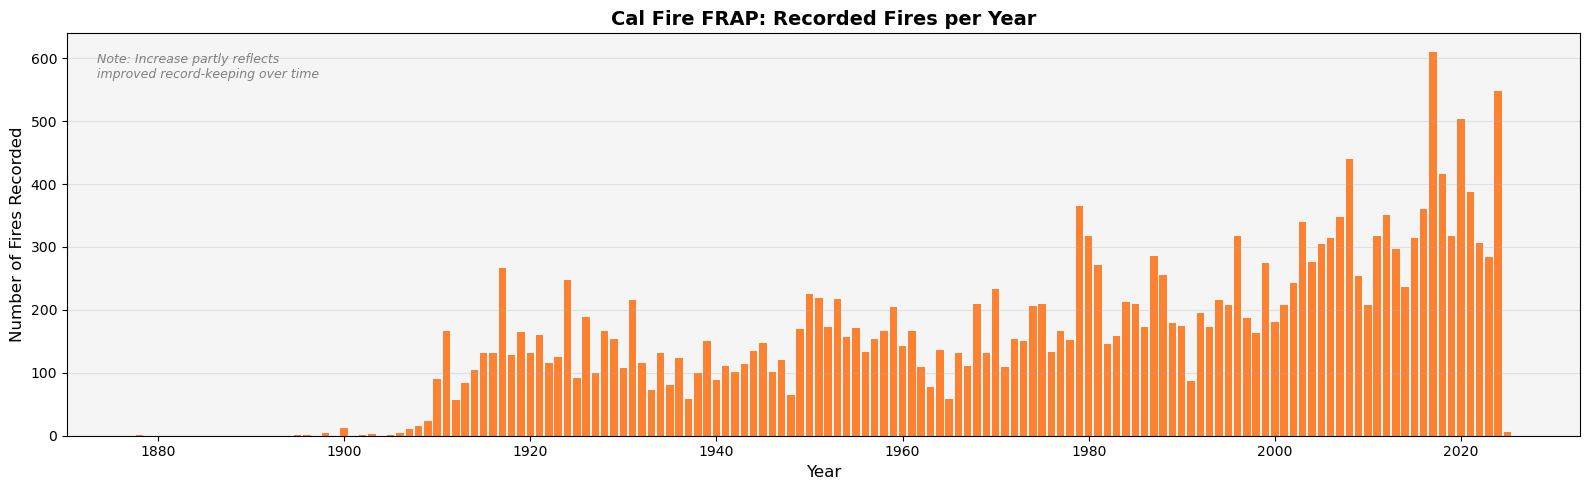

In [40]:
fig, ax = plt.subplots(figsize=(16, 5))

fires_per_year = gdf.groupby("year").size()
ax.bar(fires_per_year.index.astype(float), fires_per_year.values,
       color="#ff6600", alpha=0.8, width=0.8)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Number of Fires Recorded", fontsize=12)
ax.set_title("Cal Fire FRAP: Recorded Fires per Year", fontsize=14, fontweight="bold")
ax.set_facecolor("#f5f5f5")
ax.grid(axis="y", alpha=0.3)
ax.annotate(
    "Note: Increase partly reflects\nimproved record-keeping over time",
    xy=(0.02, 0.95), xycoords="axes fraction", fontsize=9,
    va="top", color="gray", fontstyle="italic",
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fires_per_year.png", dpi=150, bbox_inches="tight")
plt.show()


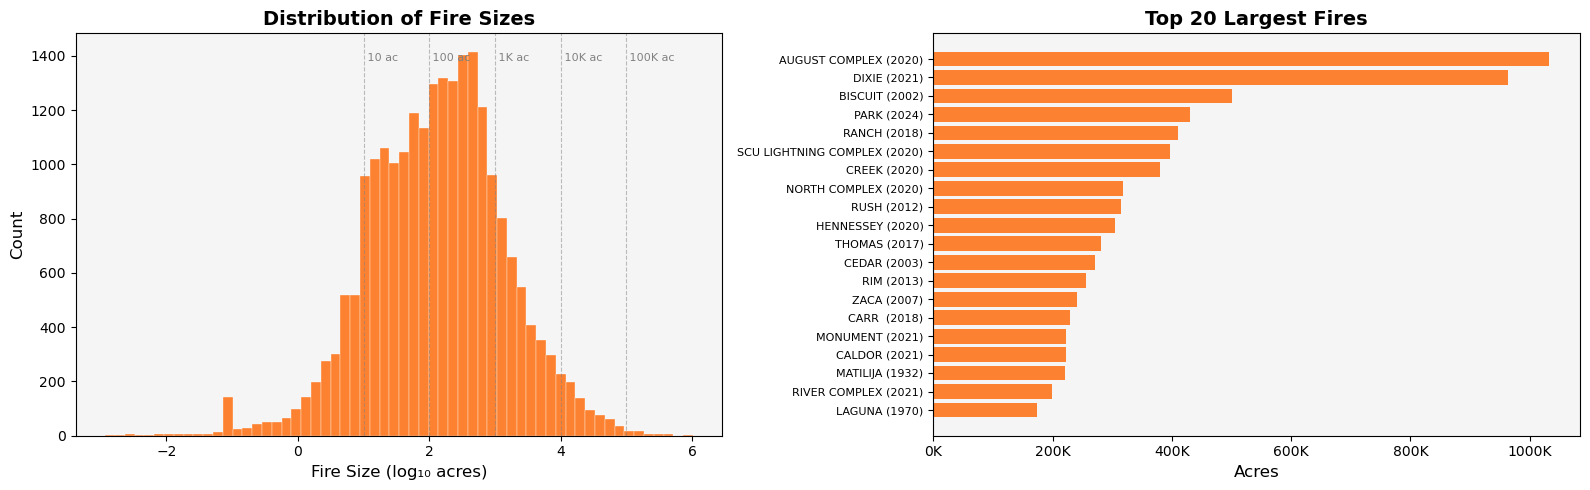


Top 20 Largest Fires:
            fire_name  year        acres
       AUGUST COMPLEX  2020 1.032700e+06
                DIXIE  2021 9.634054e+05
              BISCUIT  2002 5.010820e+05
                 PARK  2024 4.296028e+05
                RANCH  2018 4.102025e+05
SCU LIGHTNING COMPLEX  2020 3.968245e+05
                CREEK  2020 3.798424e+05
        NORTH COMPLEX  2020 3.187972e+05
                 RUSH  2012 3.155115e+05
            HENNESSEY  2020 3.053519e+05
               THOMAS  2017 2.817909e+05
                CEDAR  2003 2.706860e+05
                  RIM  2013 2.561755e+05
                 ZACA  2007 2.403587e+05
                CARR   2018 2.296514e+05
             MONUMENT  2021 2.231079e+05
               CALDOR  2021 2.217864e+05
             MATILIJA  1932 2.199993e+05
        RIVER COMPLEX  2021 1.993541e+05
               LAGUNA  1970 1.741615e+05


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of fire sizes (log scale)
ax = axes[0]
valid_acres = gdf["acres"].dropna()
valid_acres = valid_acres[valid_acres > 0]
ax.hist(np.log10(valid_acres), bins=60, color="#ff6600", alpha=0.8, edgecolor="white", linewidth=0.3)
ax.set_xlabel("Fire Size (log₁₀ acres)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Distribution of Fire Sizes", fontsize=14, fontweight="bold")
# Add reference lines
for threshold, label in [(10, "10 ac"), (100, "100 ac"), (1000, "1K ac"),
                          (10000, "10K ac"), (100000, "100K ac")]:
    ax.axvline(np.log10(threshold), color="gray", linestyle="--", alpha=0.5, linewidth=0.8)
    ax.text(np.log10(threshold), ax.get_ylim()[1] * 0.95, f" {label}", fontsize=8,
            color="gray", va="top")
ax.set_facecolor("#f5f5f5")

# Top 20 largest fires
ax = axes[1]
top_fires = (
    gdf.nlargest(20, "acres")[["fire_name", "year", "acres"]]
    .reset_index(drop=True)
)
ax.barh(range(len(top_fires)), top_fires["acres"],
        color="#ff6600", alpha=0.8)
ax.set_yticks(range(len(top_fires)))
ax.set_yticklabels(
    [f"{row.fire_name} ({int(row.year)})" for _, row in top_fires.iterrows()],
    fontsize=8,
)
ax.set_xlabel("Acres", fontsize=12)
ax.set_title("Top 20 Largest Fires", fontsize=14, fontweight="bold")
ax.invert_yaxis()
ax.set_facecolor("#f5f5f5")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fire_size_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 20 Largest Fires:")
print(top_fires.to_string(index=False))


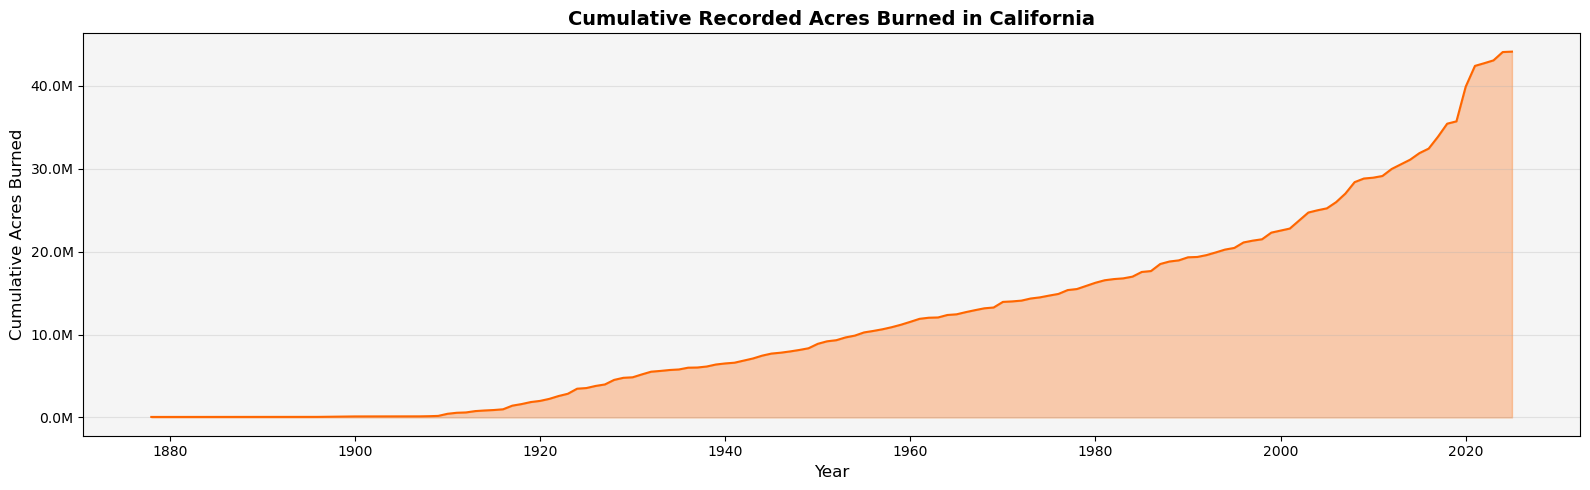

In [42]:
cumulative = (
    gdf.groupby("year")["acres"]
    .sum()
    .sort_index()
    .cumsum()
)

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(cumulative.index.astype(float), cumulative.values,
                color="#ff6600", alpha=0.3)
ax.plot(cumulative.index.astype(float), cumulative.values,
        color="#ff6600", linewidth=1.5)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Cumulative Acres Burned", fontsize=12)
ax.set_title("Cumulative Recorded Acres Burned in California", fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.set_facecolor("#f5f5f5")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cumulative_acres.png", dpi=150, bbox_inches="tight")
plt.show()


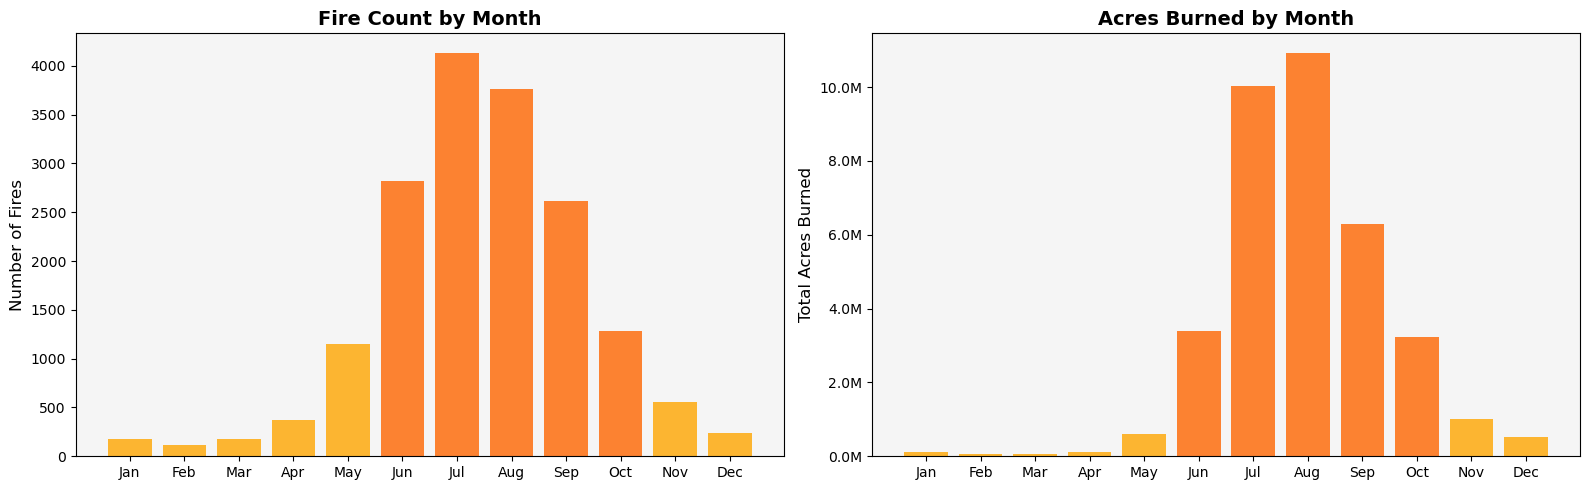

In [43]:
dated_fires = gdf[gdf["alarm_date"].notna()].copy()
dated_fires["month"] = dated_fires["alarm_date"].dt.month

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Count by month
ax = axes[0]
month_counts = dated_fires.groupby("month").size()
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
colors = ["#ff6600" if m in [6, 7, 8, 9, 10] else "#ffa500" for m in range(1, 13)]
ax.bar(range(1, 13), [month_counts.get(m, 0) for m in range(1, 13)],
       color=colors, alpha=0.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_ylabel("Number of Fires", fontsize=12)
ax.set_title("Fire Count by Month", fontsize=14, fontweight="bold")
ax.set_facecolor("#f5f5f5")

# Acres by month
ax = axes[1]
month_acres = dated_fires.groupby("month")["acres"].sum()
ax.bar(range(1, 13), [month_acres.get(m, 0) for m in range(1, 13)],
       color=colors, alpha=0.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_ylabel("Total Acres Burned", fontsize=12)
ax.set_title("Acres Burned by Month", fontsize=14, fontweight="bold")
ax.set_facecolor("#f5f5f5")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fire_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()


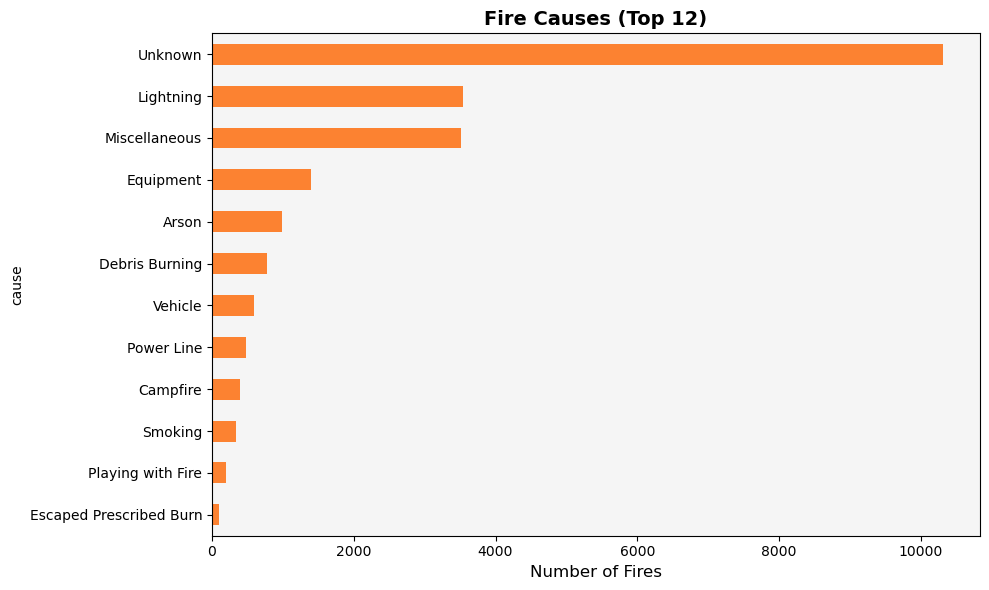

In [44]:
if gdf["cause"].notna().any():
    # FRAP cause codes: 1=Lightning, 2=Equipment Use, 4=Campfire, 5=Debris,
    # 6=Railroad, 7=Arson, 9=Miscellaneous, 10=Vehicle, 11=Power Line,
    # 14=Unknown/Unidentified, etc.
    cause_map = {
        1: "Lightning", 2: "Equipment", 3: "Smoking", 4: "Campfire",
        5: "Debris Burning", 6: "Railroad", 7: "Arson", 8: "Playing with Fire",
        9: "Miscellaneous", 10: "Vehicle", 11: "Power Line", 12: "Firefighter Training",
        13: "Non-Firefighter Training", 14: "Unknown", 15: "Structure",
        16: "Aircraft", 17: "Volcanic", 18: "Escaped Prescribed Burn", 19: "Illegal Alien Campfire"
    }

    cause_counts = (
        gdf["cause"]
        .dropna()
        .astype(int)
        .map(cause_map)
        .fillna("Other")
        .value_counts()
        .head(12)
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    cause_counts.plot(kind="barh", ax=ax, color="#ff6600", alpha=0.8)
    ax.set_xlabel("Number of Fires", fontsize=12)
    ax.set_title("Fire Causes (Top 12)", fontsize=14, fontweight="bold")
    ax.invert_yaxis()
    ax.set_facecolor("#f5f5f5")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "fire_causes.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No cause data available in this release.")


In [45]:
def get_california_boundary() -> gpd.GeoDataFrame:
    """Get California state boundary. Downloads Census TIGER if needed."""
    ca_shp = CA_BOUNDARY_PATH / "california.shp"

    if ca_shp.exists():
        print(f"✓ California boundary already cached")
        return gpd.read_file(ca_shp)

    # Try downloading Census TIGER state boundaries
    tiger_zip = RAW_DIR / "tl_2023_us_state.zip"
    if not tiger_zip.exists():
        print("Downloading California state boundary from Census TIGER...")
        try:
            resp = requests.get(CA_BOUNDARY_URL, stream=True, timeout=60)
            resp.raise_for_status()
            with open(tiger_zip, "wb") as f:
                for chunk in resp.iter_content(chunk_size=8192):
                    f.write(chunk)
            print(f"✓ Downloaded: {tiger_zip.name}")
        except Exception as e:
            print(f"⚠️  Download failed: {e}")
            tiger_zip = None

    if tiger_zip and tiger_zip.exists():
        states = gpd.read_file(f"zip://{tiger_zip}")
        ca = states[states["STUSPS"] == "CA"].copy()
        CA_BOUNDARY_PATH.mkdir(parents=True, exist_ok=True)
        ca.to_file(ca_shp)
        print(f"✓ Extracted California boundary")
        return ca

    # Fallback: extract CA outline from fire perimeters convex hull
    print("⚠️  Using convex hull of fire perimeters as fallback boundary")
    return gpd.GeoDataFrame(
        geometry=[gdf.to_crs(CRS_WGS84).unary_union.convex_hull],
        crs=CRS_WGS84,
    )


ca_boundary = get_california_boundary().to_crs(CRS_CA_ALBERS)
print(f"California boundary CRS: {ca_boundary.crs}")


✓ California boundary already cached
California boundary CRS: EPSG:3310


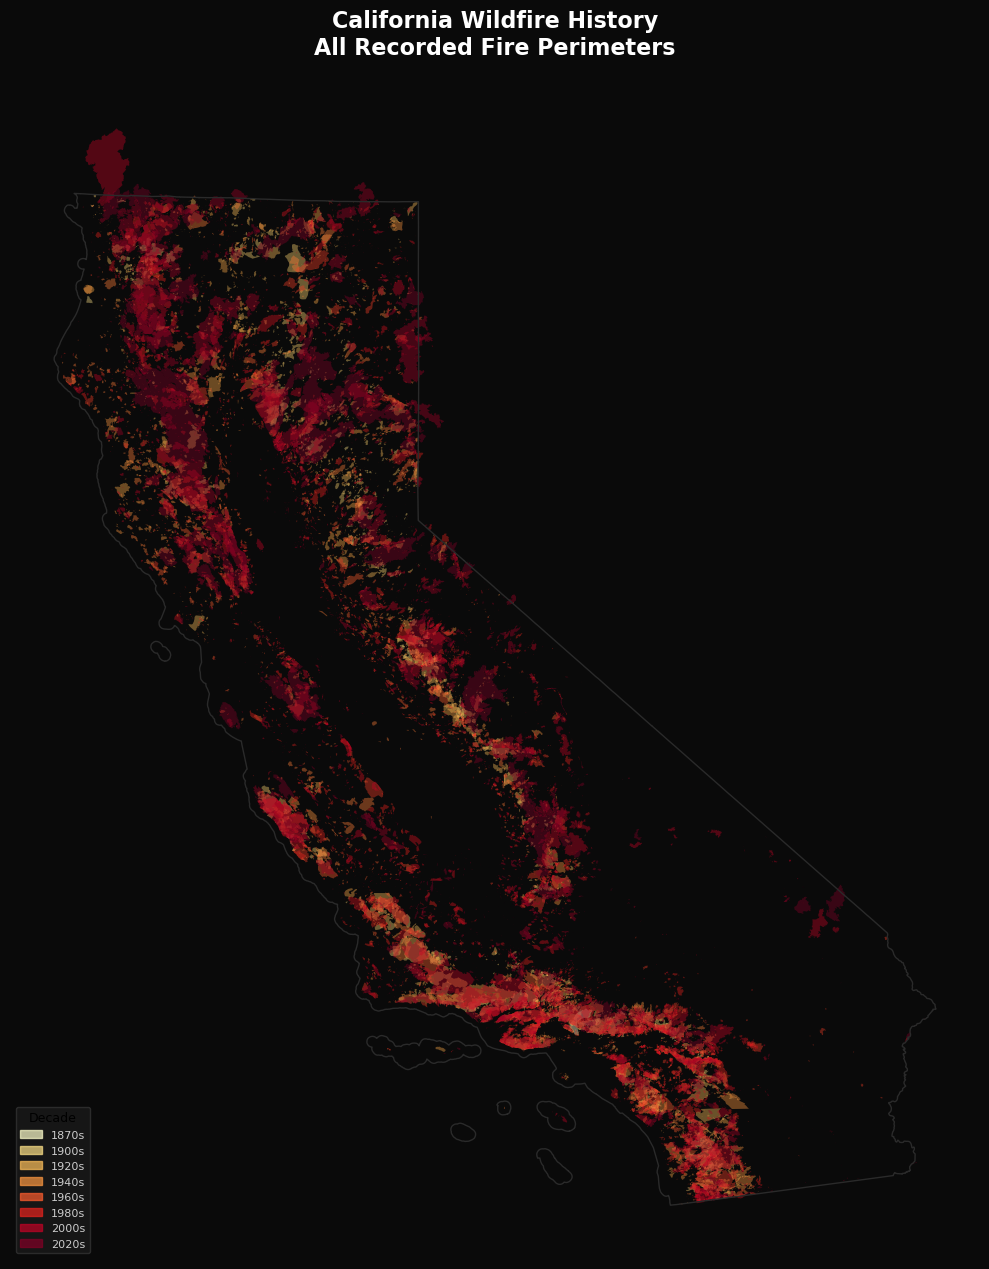

In [46]:
fig, ax = plt.subplots(figsize=(10, 14))
ax.set_facecolor(BG_COLOR)
fig.patch.set_facecolor(BG_COLOR)

# Draw California outline
ca_boundary.boundary.plot(ax=ax, color=CA_OUTLINE_COLOR, linewidth=1)

# Color fires by decade
decade_cmap = plt.cm.YlOrRd
gdf_plot = gdf[gdf["year"].notna()].copy()
gdf_plot["decade"] = (gdf_plot["year"] // 10) * 10

# Normalize decades to colormap range
min_decade = gdf_plot["decade"].min()
max_decade = gdf_plot["decade"].max()

for decade, group in gdf_plot.groupby("decade"):
    if pd.isna(decade):
        continue
    norm_val = (decade - min_decade) / (max_decade - min_decade + 1)
    color = decade_cmap(norm_val)
    group.plot(ax=ax, color=color, alpha=0.4, linewidth=0)

# Legend
unique_decades = sorted(gdf_plot["decade"].dropna().unique())
# Show every other decade to avoid clutter
legend_decades = unique_decades[::2]
legend_patches = [
    mpatches.Patch(
        color=decade_cmap((d - min_decade) / (max_decade - min_decade + 1)),
        label=f"{int(d)}s",
        alpha=0.7,
    )
    for d in legend_decades
]
ax.legend(
    handles=legend_patches, loc="lower left", fontsize=8,
    facecolor="#1a1a1a", edgecolor="#333", labelcolor=TEXT_COLOR,
    title="Decade", title_fontsize=9,
)

ax.set_title(
    "California Wildfire History\nAll Recorded Fire Perimeters",
    fontsize=16, fontweight="bold", color=YEAR_TEXT_COLOR, pad=15,
)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "all_fires_by_decade.png", dpi=200, bbox_inches="tight",
    facecolor=BG_COLOR,
)
plt.show()


In [47]:
print("\n" + "=" * 60)
print("SUMMARY: Fires by era (to help choose animation start year)")
print("=" * 60)

eras = [
    ("Pre-1900", gdf[gdf["year"] < 1900]),
    ("1900–1919", gdf[(gdf["year"] >= 1900) & (gdf["year"] < 1920)]),
    ("1920–1949", gdf[(gdf["year"] >= 1920) & (gdf["year"] < 1950)]),
    ("1950–1979", gdf[(gdf["year"] >= 1950) & (gdf["year"] < 1980)]),
    ("1980–1999", gdf[(gdf["year"] >= 1980) & (gdf["year"] < 2000)]),
    ("2000–2024", gdf[gdf["year"] >= 2000]),
]

for label, subset in eras:
    dated_pct = subset["alarm_date"].notna().mean() * 100 if len(subset) > 0 else 0
    print(
        f"  {label:<12}  {len(subset):>6,} fires  |  "
        f"{subset['acres'].sum():>12,.0f} acres  |  "
        f"{dated_pct:>5.1f}% with exact dates"
    )

print(f"\n→ Current animation start year in config: {ANIMATION_START_YEAR}")
print(f"  (Change ANIMATION_START_YEAR in config.py to adjust)")



SUMMARY: Fires by era (to help choose animation start year)
  Pre-1900           8 fires  |        95,873 acres  |   37.5% with exact dates
  1900–1919      1,394 fires  |     1,760,817 acres  |   18.5% with exact dates
  1920–1949      3,791 fires  |     6,490,134 acres  |   32.5% with exact dates
  1950–1979      4,974 fires  |     7,526,338 acres  |   79.9% with exact dates
  1980–1999      4,200 fires  |     6,429,362 acres  |   86.5% with exact dates
  2000–2024      8,366 fires  |    21,843,732 acres  |   99.4% with exact dates

→ Current animation start year in config: 2000
  (Change ANIMATION_START_YEAR in config.py to adjust)


In [48]:
print("Simplifying geometries for faster rendering...")
gdf_simplified = gdf.copy()
gdf_simplified["geometry"] = gdf.geometry.simplify(
    tolerance=SIMPLIFY_TOLERANCE_M, preserve_topology=True
)

# Quick size comparison
orig_size = gdf.geometry.memory_usage(deep=True) / 1e6
simp_size = gdf_simplified.geometry.memory_usage(deep=True) / 1e6
print(f"  Geometry memory: {orig_size:.1f} MB → {simp_size:.1f} MB")

# Drop columns that GeoPackage can't serialize
cols_to_drop = [c for c in ["alarm_month", "time_sort", "alarm_date", "cont_date", "fire_name", "cause"] if c in gdf_simplified.columns]
gdf_simplified = gdf_simplified.drop(columns=cols_to_drop)

# Save to processed dir for use by other notebooks
processed_path = PROCESSED_DIR / "fire_perimeters_processed.gpkg"
gdf_simplified.to_file(processed_path, driver="GPKG")
print(f"✓ Saved processed data: {processed_path}")
print(f"  File size: {processed_path.stat().st_size / 1e6:.1f} MB")

# Also save a WGS84 version for web maps
gdf_wgs84 = gdf_simplified.to_crs(CRS_WGS84)
wgs84_path = PROCESSED_DIR / "fire_perimeters_wgs84.gpkg"
gdf_wgs84.to_file(wgs84_path, driver="GPKG")
print(f"✓ Saved WGS84 version: {wgs84_path}")

print(f"\n{'='*60}")
print(f"Section B complete! Ready for interactive exploration (Section C).")
print(f"{'='*60}")
print(f"\nKey numbers:")
print(f"  Total fire records:    {len(gdf):,}")
print(f"  Year range:            {gdf['year'].min()} — {gdf['year'].max()}")
print(f"  With exact dates:      {gdf['alarm_date'].notna().sum():,}")
print(f"  Unique time bins:      {gdf['time_bin'].nunique():,}")
print(f"  Total acres in dataset: {gdf['acres'].sum():,.0f}")

Simplifying geometries for faster rendering...


/opt/anaconda3/envs/openfire/lib/python3.11/site-packages/shapely/constructive.py:1177: RuntimeWarning: invalid value encountered in simplify_preserve_topology
  return lib.simplify_preserve_topology(geometry, tolerance, **kwargs)


  Geometry memory: 0.2 MB → 0.2 MB
✓ Saved processed data: /Users/tomas/Documents/02d-USF-MSDS/MSDS603/openfire/data/processed/fire_perimeters_processed.gpkg
  File size: 9.6 MB
✓ Saved WGS84 version: /Users/tomas/Documents/02d-USF-MSDS/MSDS603/openfire/data/processed/fire_perimeters_wgs84.gpkg

Section B complete! Ready for interactive exploration (Section C).

Key numbers:
  Total fire records:    22,810
  Year range:            1878 — 2025
  With exact dates:      17,414
  Unique time bins:      1,144
  Total acres in dataset: 44,184,184


# Section C — AOI Selection: Where Burns Most in California?

**Goal:** Identify the best area of interest (AOI) for OpenFire's ML pipeline.

**Criteria for a good AOI:**
- High fire frequency (2000–2025) — gives us plenty of training labels
- Active in Sentinel-2 era (2015+) — so we have satellite imagery
- Manageable geographic scope — one or a few counties
- Mix of fire sizes — not just one mega-fire dominating

**Approach:** Rasterize fire perimeters onto a grid, count burns per cell,
then aggregate by county to rank candidate AOIs.

In [49]:
# C1: Filter to 2000+ fires
gdf_modern = gdf[gdf["year"] >= 2000].copy()
gdf_s2 = gdf[gdf["year"] >= 2015].copy()

print(f"All fires:       {len(gdf):,}")
print(f"Since 2000:      {len(gdf_modern):,} fires, {gdf_modern['acres'].sum():,.0f} acres")
print(f"Since 2015 (S2): {len(gdf_s2):,} fires, {gdf_s2['acres'].sum():,.0f} acres")
print(f"\nFires per year (2000+):")
print(gdf_modern.groupby("year").size().to_string())

All fires:       22,810
Since 2000:      8,366 fires, 21,843,732 acres
Since 2015 (S2): 4,054 fires, 13,038,745 acres

Fires per year (2000+):
year
2000    180
2001    207
2002    243
2003    340
2004    276
2005    304
2006    314
2007    348
2008    439
2009    254
2010    207
2011    317
2012    351
2013    296
2014    236
2015    314
2016    361
2017    609
2018    416
2019    318
2020    504
2021    388
2022    306
2023    284
2024    548
2025      6


In [50]:
# C2: Rasterize — count how many times each grid cell burned (2000+)
import rasterio
from rasterio.transform import from_bounds
from rasterio.features import rasterize

# Use California bounds from our boundary file
ca_bounds = ca_boundary.total_bounds  # [minx, miny, maxx, maxy]
res = RASTER_RESOLUTION_M

# Compute grid dimensions
width = int((ca_bounds[2] - ca_bounds[0]) / res)
height = int((ca_bounds[3] - ca_bounds[1]) / res)
transform = from_bounds(*ca_bounds, width, height)

print(f"Grid: {width} x {height} = {width * height:,} cells at {res}m resolution")

# Rasterize: for each fire, burn a 1 into its footprint, then sum
burn_count = np.zeros((height, width), dtype=np.int16)

for _, row in tqdm(gdf_modern.iterrows(), total=len(gdf_modern), desc="Rasterizing 2000+ fires"):
    if row.geometry is None or row.geometry.is_empty:
        continue
    try:
        raster = rasterize(
            [(row.geometry, 1)],
            out_shape=(height, width),
            transform=transform,
            fill=0,
            dtype="uint8",
        )
        burn_count += raster
    except Exception:
        continue

print(f"\nBurn count stats:")
print(f"  Max burns in one cell: {burn_count.max()}")
print(f"  Cells burned at least once: {(burn_count >= 1).sum():,}")
print(f"  Cells burned 2+ times: {(burn_count >= 2).sum():,}")
print(f"  Cells burned 3+ times: {(burn_count >= 3).sum():,}")

Grid: 920 x 1055 = 970,600 cells at 1000m resolution


Rasterizing 2000+ fires: 100%|██████████| 8366/8366 [00:09<00:00, 919.86it/s] 


Burn count stats:
  Max burns in one cell: 6
  Cells burned at least once: 74,889
  Cells burned 2+ times: 10,484
  Cells burned 3+ times: 624


In [51]:
# C3: Same thing for Sentinel-2 era (2015+)
burn_count_s2 = np.zeros((height, width), dtype=np.int16)

for _, row in tqdm(gdf_s2.iterrows(), total=len(gdf_s2), desc="Rasterizing 2015+ fires"):
    if row.geometry is None or row.geometry.is_empty:
        continue
    try:
        raster = rasterize(
            [(row.geometry, 1)],
            out_shape=(height, width),
            transform=transform,
            fill=0,
            dtype="uint8",
        )
        burn_count_s2 += raster
    except Exception:
        continue

print(f"\nBurn count stats (Sentinel-2 era, 2015+):")
print(f"  Max burns in one cell: {burn_count_s2.max()}")
print(f"  Cells burned at least once: {(burn_count_s2 >= 1).sum():,}")
print(f"  Cells burned 2+ times: {(burn_count_s2 >= 2).sum():,}")

Rasterizing 2015+ fires: 100%|██████████| 4054/4054 [00:04<00:00, 895.43it/s] 


Burn count stats (Sentinel-2 era, 2015+):
  Max burns in one cell: 4
  Cells burned at least once: 51,031
  Cells burned 2+ times: 1,415


/var/folders/8q/48hstyms4z79cf6rxhybh5340000gn/T/ipykernel_34072/2121836131.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


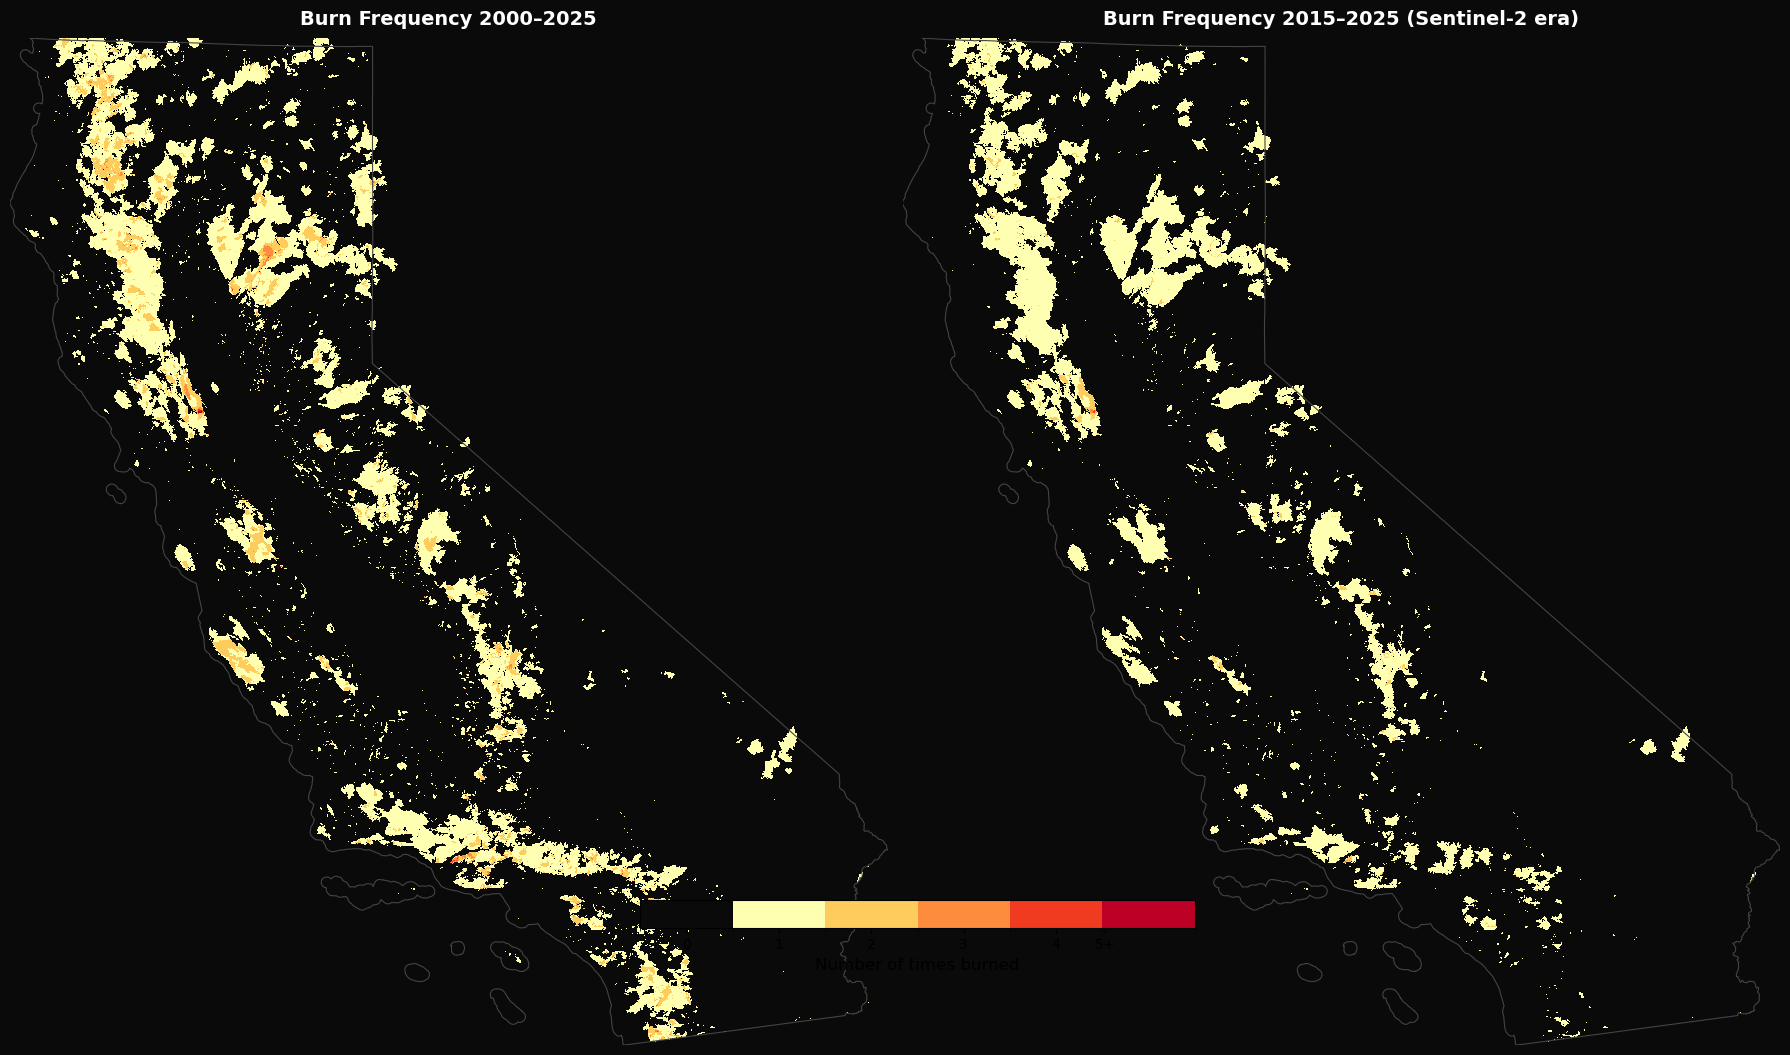

In [52]:
# C4: Heatmap — burn frequency since 2000
from matplotlib.colors import BoundaryNorm, ListedColormap

fig, axes = plt.subplots(1, 2, figsize=(18, 12))

# Custom colormap: 0=transparent, 1=yellow, 2=orange, 3+=red
cmap_colors = ["#0a0a0a", "#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026"]
cmap = ListedColormap(cmap_colors)
bounds_cm = [0, 0.5, 1.5, 2.5, 3.5, 4.5, 20]
norm = BoundaryNorm(bounds_cm, cmap.N)

for ax, data, title in [
    (axes[0], burn_count, "Burn Frequency 2000–2025"),
    (axes[1], burn_count_s2, "Burn Frequency 2015–2025 (Sentinel-2 era)"),
]:
    ax.set_facecolor(BG_COLOR)
    ca_boundary.boundary.plot(ax=ax, color="#444444", linewidth=0.8)
    
    # Convert raster to map coordinates for imshow
    extent = [ca_bounds[0], ca_bounds[2], ca_bounds[1], ca_bounds[3]]
    im = ax.imshow(
        np.flipud(data), extent=extent, origin="lower",
        cmap=cmap, norm=norm, interpolation="nearest",
    )
    
    ax.set_title(title, fontsize=14, fontweight="bold", color="white", pad=10)
    ax.set_axis_off()
    ax.set_aspect("equal")

# Colorbar
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", fraction=0.03, pad=0.04)
cbar.set_ticks([0.25, 1, 2, 3, 4, 5])
cbar.set_ticklabels(["0", "1", "2", "3", "4", "5+"])
cbar.set_label("Number of times burned", fontsize=12)

fig.patch.set_facecolor(BG_COLOR)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "burn_frequency_heatmap.png", dpi=150, bbox_inches="tight", facecolor=BG_COLOR)
plt.show()

In [53]:
# C5: Load county boundaries and aggregate burn stats per county
# Using Census TIGER county boundaries
import urllib.request

county_zip = RAW_DIR / "tl_2023_06_cousub.zip"
county_url = "https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip"

county_path = RAW_DIR / "counties"
county_shp = county_path / "ca_counties.shp"

if not county_shp.exists():
    # Download county boundaries
    county_zip = RAW_DIR / "tl_2023_us_county.zip"
    if not county_zip.exists():
        print("Downloading county boundaries...")
        resp = requests.get(county_url, timeout=60)
        resp.raise_for_status()
        with open(county_zip, "wb") as f:
            f.write(resp.content)
        print(f"✓ Downloaded {county_zip.name}")
    
    # Extract California counties (FIPS state code 06)
    counties_all = gpd.read_file(f"zip://{county_zip}")
    ca_counties = counties_all[counties_all["STATEFP"] == "06"].copy()
    county_path.mkdir(parents=True, exist_ok=True)
    ca_counties.to_file(county_shp)
    print(f"✓ Extracted {len(ca_counties)} California counties")
else:
    ca_counties = gpd.read_file(county_shp)
    print(f"✓ Loaded {len(ca_counties)} California counties")

ca_counties = ca_counties.to_crs(CRS_CA_ALBERS)
print(f"Counties: {', '.join(sorted(ca_counties['NAME'].tolist())[:10])}...")

✓ Loaded 58 California counties
Counties: Alameda, Alpine, Amador, Butte, Calaveras, Colusa, Contra Costa, Del Norte, El Dorado, Fresno...


In [54]:
# C6: Per-county fire stats — the key ranking table

county_stats = []

for _, county in ca_counties.iterrows():
    county_name = county["NAME"]
    county_geom = county.geometry
    
    # Fires since 2000 that intersect this county
    fires_2000 = gdf_modern[gdf_modern.intersects(county_geom)]
    # Fires since 2015 (Sentinel-2 era)
    fires_s2 = gdf_s2[gdf_s2.intersects(county_geom)]
    
    # Total burned area (clipped to county)
    try:
        burned_2000 = fires_2000.clip(county_geom)
        acres_2000 = burned_2000.geometry.area.sum() / 4046.86  # sq m to acres
    except Exception:
        acres_2000 = fires_2000["acres"].sum()
    
    try:
        burned_s2 = fires_s2.clip(county_geom)
        acres_s2 = burned_s2.geometry.area.sum() / 4046.86
    except Exception:
        acres_s2 = fires_s2["acres"].sum()
    
    county_area_acres = county_geom.area / 4046.86
    
    county_stats.append({
        "county": county_name,
        "fires_2000": len(fires_2000),
        "fires_s2": len(fires_s2),
        "acres_burned_2000": acres_2000,
        "acres_burned_s2": acres_s2,
        "county_acres": county_area_acres,
        "pct_burned_2000": (acres_2000 / county_area_acres * 100) if county_area_acres > 0 else 0,
        "pct_burned_s2": (acres_s2 / county_area_acres * 100) if county_area_acres > 0 else 0,
    })

county_df = pd.DataFrame(county_stats)

# Sort by number of fires in S2 era (what matters most for our ML pipeline)
county_df = county_df.sort_values("fires_s2", ascending=False).reset_index(drop=True)

print("\nTop 15 counties by fire count (Sentinel-2 era, 2015+):")
print("=" * 90)
print(f"{'County':<20} {'Fires S2':>10} {'Acres S2':>12} {'%Burned S2':>10} {'Fires 2000+':>12} {'Acres 2000+':>14}")
print("-" * 90)
for _, row in county_df.head(15).iterrows():
    print(
        f"{row['county']:<20} {row['fires_s2']:>10,} {row['acres_burned_s2']:>12,.0f} "
        f"{row['pct_burned_s2']:>9.1f}% {row['fires_2000']:>12,} {row['acres_burned_2000']:>14,.0f}"
    )

/opt/anaconda3/envs/openfire/lib/python3.11/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/openfire/lib/python3.11/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/openfire/lib/python3.11/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/opt/anaconda3/envs/openfire/lib/python3.11/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/opt/anaconda3/envs/openfire/lib/python3.11/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/openfire/lib/python3.11/site-packages/shapely/predicates.py


Top 15 counties by fire count (Sentinel-2 era, 2015+):
County                 Fires S2     Acres S2 %Burned S2  Fires 2000+    Acres 2000+
------------------------------------------------------------------------------------------
Kern                        526      249,859       4.8%          816        517,309
Los Angeles                 279      444,016      14.6%          614        994,815
San Luis Obispo             252       89,813       3.9%          365        114,171
Siskiyou                    215    1,023,124      25.2%          462      1,598,704
Ventura                     187      322,781      22.9%          278        783,211
San Diego                   178       61,677       2.1%          386      1,025,150
Fresno                      155      500,659      13.0%          290        598,569
Riverside                   131      151,691       3.2%          369        373,920
San Bernardino              128      324,194       2.5%          311        735,444
Mariposa     

/opt/anaconda3/envs/openfire/lib/python3.11/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/opt/anaconda3/envs/openfire/lib/python3.11/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


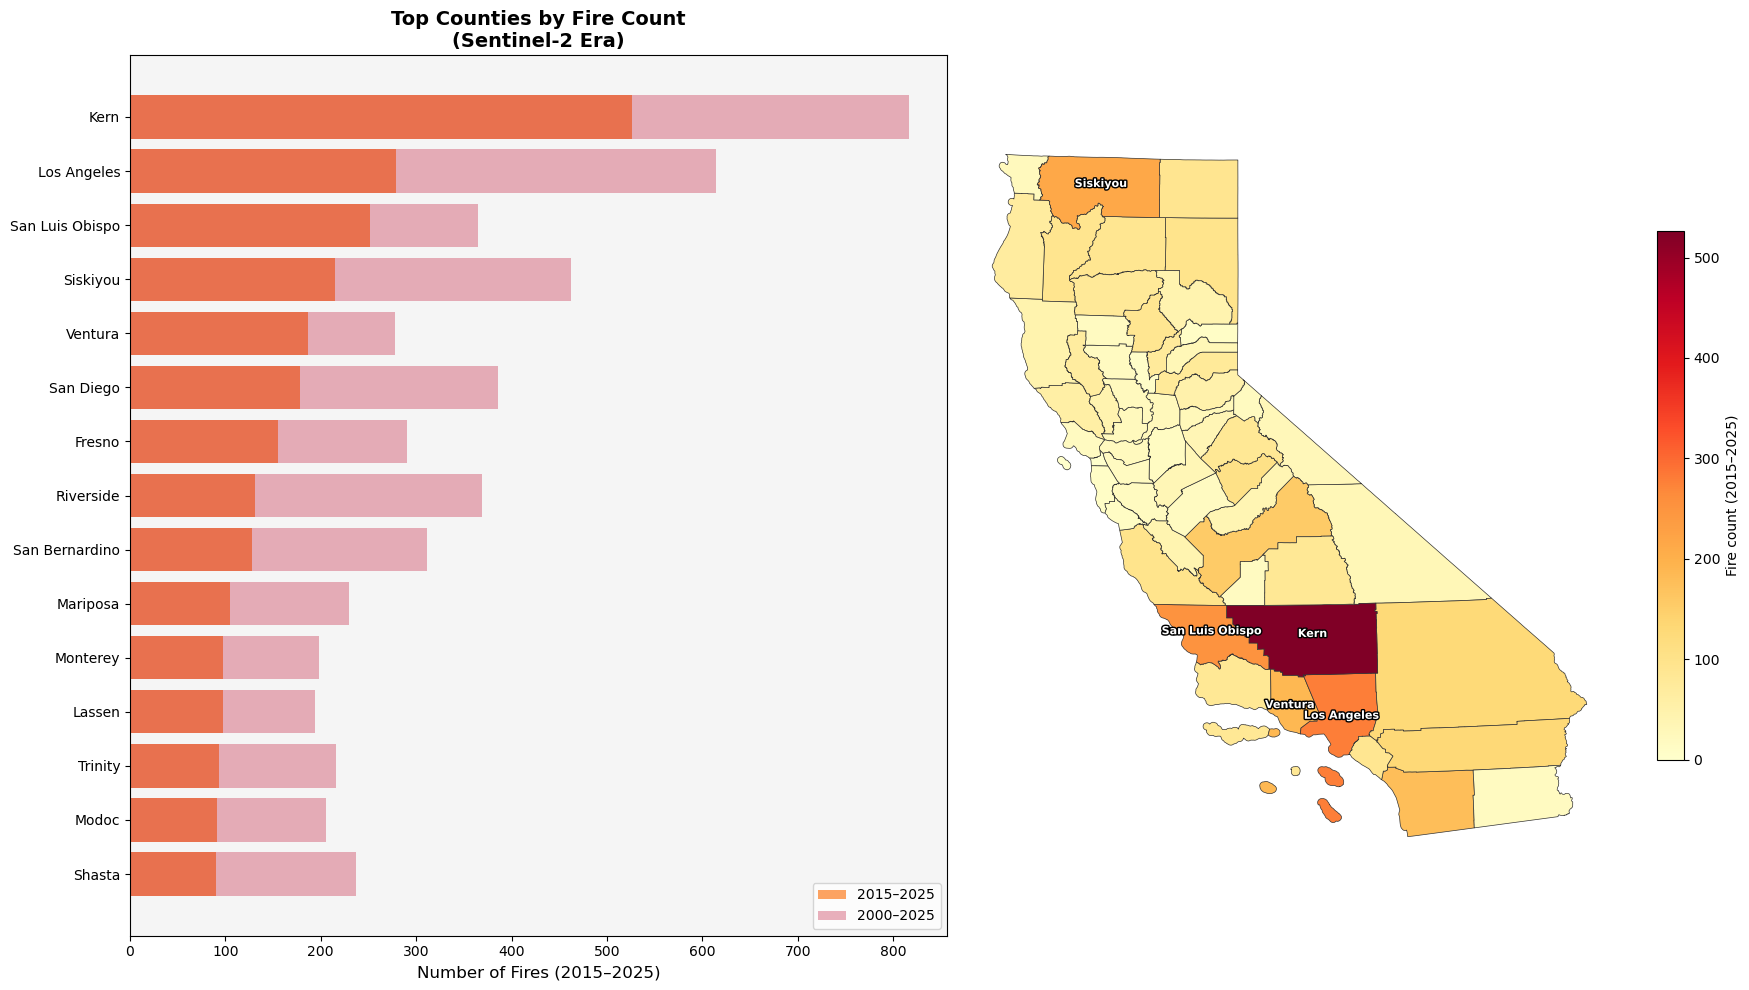

In [55]:
# C7: Visual — top counties bar chart + map
import matplotlib.patheffects as pe

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Bar chart: top 15 by S2-era fire count
ax = axes[0]
top15 = county_df.head(15)
bars = ax.barh(range(len(top15)), top15["fires_s2"], color="#fd8d3c", alpha=0.8)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15["county"])
ax.set_xlabel("Number of Fires (2015–2025)", fontsize=12)
ax.set_title("Top Counties by Fire Count\n(Sentinel-2 Era)", fontsize=14, fontweight="bold")
ax.invert_yaxis()
ax.set_facecolor("#f5f5f5")

# Add second bar for 2000+ fires in lighter color
ax.barh(range(len(top15)), top15["fires_2000"], color="#bd0026", alpha=0.3)
ax.legend(["2015–2025", "2000–2025"], loc="lower right")

# Map: color counties by S2 fire count
ax = axes[1]
ax.set_facecolor(BG_COLOR)

county_merged = ca_counties.merge(county_df, left_on="NAME", right_on="county", how="left")
county_merged["fires_s2"] = county_merged["fires_s2"].fillna(0)

county_merged.plot(
    ax=ax, column="fires_s2", cmap="YlOrRd", linewidth=0.5,
    edgecolor="#333333", legend=True,
    legend_kwds={"label": "Fire count (2015–2025)", "shrink": 0.6},
)

# Label top 5 counties
for _, row in county_merged.nlargest(5, "fires_s2").iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        row["NAME"], (centroid.x, centroid.y),
        fontsize=8, fontweight="bold", color="white", ha="center",
        path_effects=[pe.withStroke(linewidth=2, foreground="black")],
    )

ax.set_title("Fire Frequency by County\n(Sentinel-2 Era)", fontsize=14, fontweight="bold", color="white")
ax.set_axis_off()

fig.patch.set_facecolor("white")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "county_fire_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

Zooming into candidates: ['Kern', 'Los Angeles', 'San Luis Obispo', 'Ventura', 'Santa Barbara']


/opt/anaconda3/envs/openfire/lib/python3.11/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/openfire/lib/python3.11/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/openfire/lib/python3.11/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/openfire/lib/python3.11/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/openfire/lib/python3.11/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


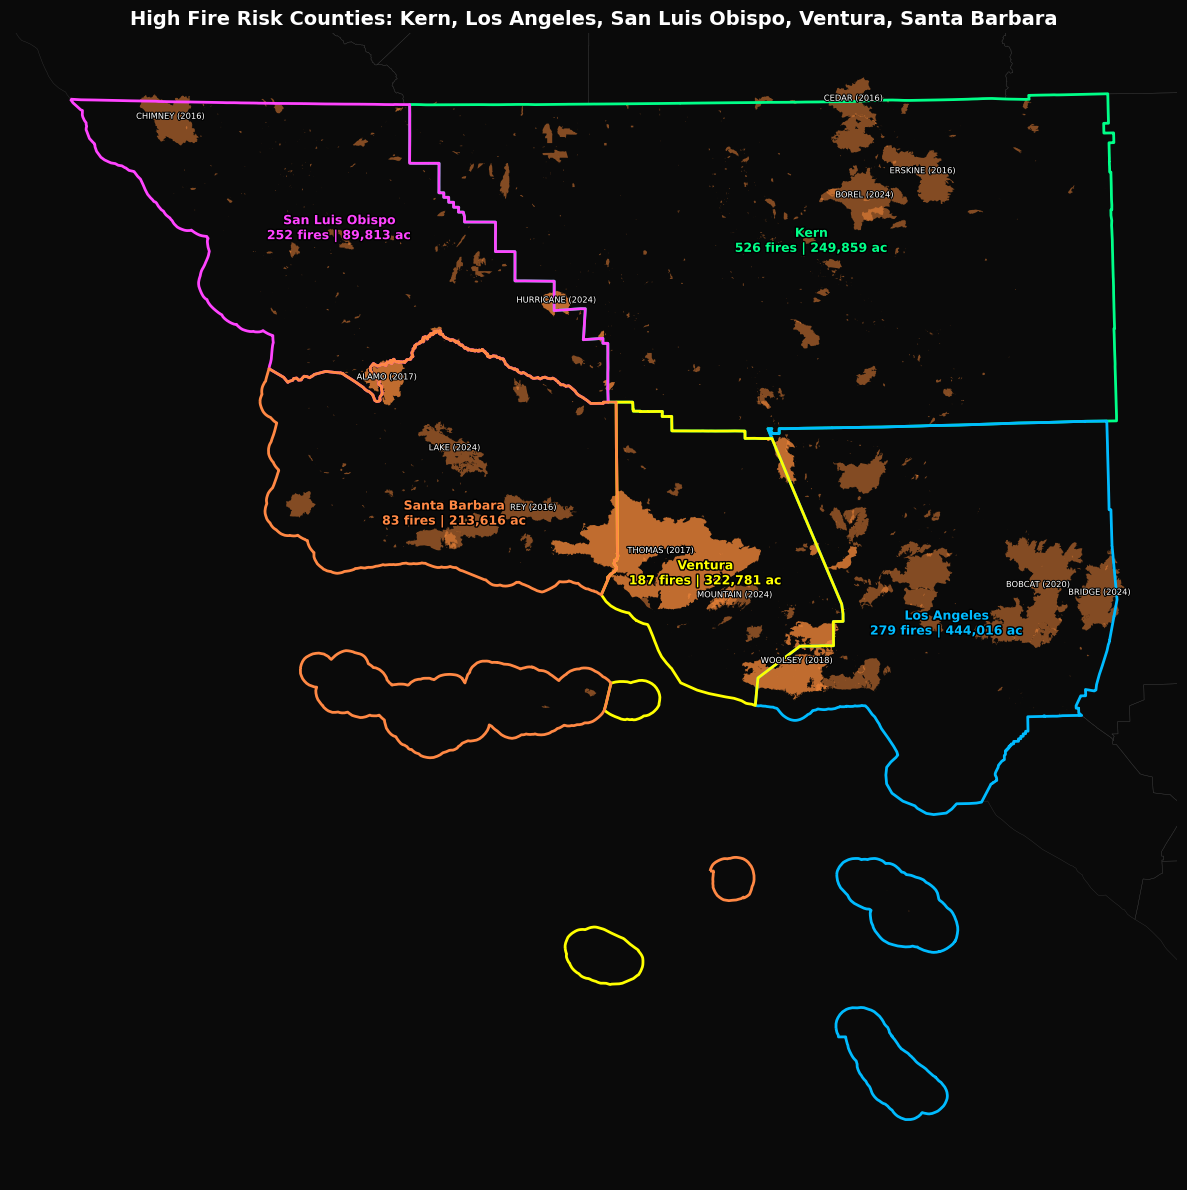

In [61]:
# C8: Zoom into top candidate counties — single map showing spatial context
import matplotlib.patheffects as pe

top3 = county_df.head(3)["county"].tolist()
extras = ["Ventura", "Santa Barbara"]
for c in extras:
    if c not in top3:
        top3.append(c)
print(f"Zooming into candidates: {top3}")

fig, ax = plt.subplots(figsize=(14, 12))
ax.set_facecolor(BG_COLOR)

# Get combined bounds of all 3 counties (with padding)
top3_counties = ca_counties[ca_counties["NAME"].isin(top3)]
combined_bounds = top3_counties.total_bounds
pad = 20000  # 20km padding

# Draw all CA counties in dim for context
ca_counties.boundary.plot(ax=ax, color="#333333", linewidth=0.3)

# Highlight the top 3 counties with distinct outlines
colors_outline = ["#00ff88", "#00bbff", "#ff44ff", "#ffff00", "#ff8844"]
for i, county_name in enumerate(top3):
    county_row = ca_counties[ca_counties["NAME"] == county_name]
    county_row.boundary.plot(ax=ax, color=colors_outline[i], linewidth=2)

    # Label the county
    centroid = county_row.geometry.iloc[0].centroid
    stats = county_df[county_df["county"] == county_name].iloc[0]
    ax.annotate(
        f"{county_name}\n{int(stats['fires_s2'])} fires | {stats['acres_burned_s2']:,.0f} ac",
        (centroid.x, centroid.y), fontsize=9, fontweight="bold",
        color=colors_outline[i], ha="center",
        path_effects=[pe.withStroke(linewidth=2, foreground="black")],
    )

# Draw S2-era fires in all 3 counties
for i, county_name in enumerate(top3):
    county_geom = ca_counties[ca_counties["NAME"] == county_name].geometry.iloc[0]
    fires_here = gdf_s2[gdf_s2.intersects(county_geom)]
    if not fires_here.empty:
        fires_here.plot(ax=ax, color="#fd8d3c", alpha=0.5, linewidth=0)

        # Label biggest fires
        for _, fire in fires_here.nlargest(3, "acres").iterrows():
            c = fire.geometry.centroid
            ax.annotate(
                f"{fire['fire_name']} ({int(fire['year'])})",
                (c.x, c.y), fontsize=6, color="white", ha="center",
                path_effects=[pe.withStroke(linewidth=1.5, foreground="black")],
            )

ax.set_xlim(combined_bounds[0] - pad, combined_bounds[2] + pad)
ax.set_ylim(combined_bounds[1] - pad, combined_bounds[3] + pad)
ax.set_title(
    f"High Fire Risk Counties: {', '.join(top3)}",
    fontsize=14, fontweight="bold", color="white",
)
ax.set_axis_off()

fig.patch.set_facecolor(BG_COLOR)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top3_county_detail.png", dpi=150, bbox_inches="tight", facecolor=BG_COLOR)
plt.show()

In [57]:
# C9: Generate GEE-ready bounding box for the chosen AOI
# Change this to whichever county (or counties) you pick

CHOSEN_COUNTIES = [county_df.iloc[0]["county"]]  # Top county by default
# Uncomment below to pick manually:
# CHOSEN_COUNTIES = ["Butte"]  # or ["Butte", "Plumas"] for multi-county

aoi_counties = ca_counties[ca_counties["NAME"].isin(CHOSEN_COUNTIES)]
aoi_geom = aoi_counties.dissolve().geometry.iloc[0]

# Get bounding box in WGS84 (for GEE)
aoi_wgs84 = aoi_counties.to_crs(CRS_WGS84).dissolve()
aoi_bbox = aoi_wgs84.total_bounds  # [minx, miny, maxx, maxy] = [west, south, east, north]

print(f"Chosen AOI: {', '.join(CHOSEN_COUNTIES)} County")
print(f"\nBounding box (WGS84):")
print(f"  West:  {aoi_bbox[0]:.4f}")
print(f"  South: {aoi_bbox[1]:.4f}")
print(f"  East:  {aoi_bbox[2]:.4f}")
print(f"  North: {aoi_bbox[3]:.4f}")

# GEE JavaScript format
print(f"\n// Google Earth Engine (JavaScript):")
print(f"var aoi = ee.Geometry.Rectangle([{aoi_bbox[0]:.4f}, {aoi_bbox[1]:.4f}, {aoi_bbox[2]:.4f}, {aoi_bbox[3]:.4f}]);")

# GEE Python format
print(f"\n# Google Earth Engine (Python):")
print(f"aoi = ee.Geometry.Rectangle([{aoi_bbox[0]:.4f}, {aoi_bbox[1]:.4f}, {aoi_bbox[2]:.4f}, {aoi_bbox[3]:.4f}])")

# Fire summary for chosen AOI
aoi_fires_s2 = gdf_s2[gdf_s2.intersects(aoi_geom)]
aoi_fires_2000 = gdf_modern[gdf_modern.intersects(aoi_geom)]

print(f"\nAOI fire summary:")
print(f"  Fires 2000–2025: {len(aoi_fires_2000):,}")
print(f"  Fires 2015–2025: {len(aoi_fires_s2):,}")
print(f"  Acres 2015–2025: {aoi_fires_s2['acres'].sum():,.0f}")
print(f"\nTop 10 fires in AOI (2015+):")
print(aoi_fires_s2.nlargest(10, 'acres')[['fire_name', 'year', 'acres']].to_string(index=False))

Chosen AOI: Kern County

Bounding box (WGS84):
  West:  -120.1944
  South: 34.7887
  East:  -117.6165
  North: 35.7984

// Google Earth Engine (JavaScript):
var aoi = ee.Geometry.Rectangle([-120.1944, 34.7887, -117.6165, 35.7984]);

# Google Earth Engine (Python):
aoi = ee.Geometry.Rectangle([-120.1944, 34.7887, -117.6165, 35.7984])


/opt/anaconda3/envs/openfire/lib/python3.11/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)



AOI fire summary:
  Fires 2000–2025: 816
  Fires 2015–2025: 526
  Acres 2015–2025: 274,755

Top 10 fires in AOI (2015+):
 fire_name  year        acres
     BOREL  2024 59288.542969
   ERSKINE  2016 48008.351562
     CEDAR  2016 29100.558594
    FRENCH  2021 26535.056641
 HURRICANE  2024 13279.426758
    RANCHO  2024  9637.176758
STAGECOACH  2020  7750.637207
     WHITE  2024  5562.287598
    ALMOND  2023  5228.871094
LOST HILLS  2024  4044.124268


/opt/anaconda3/envs/openfire/lib/python3.11/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


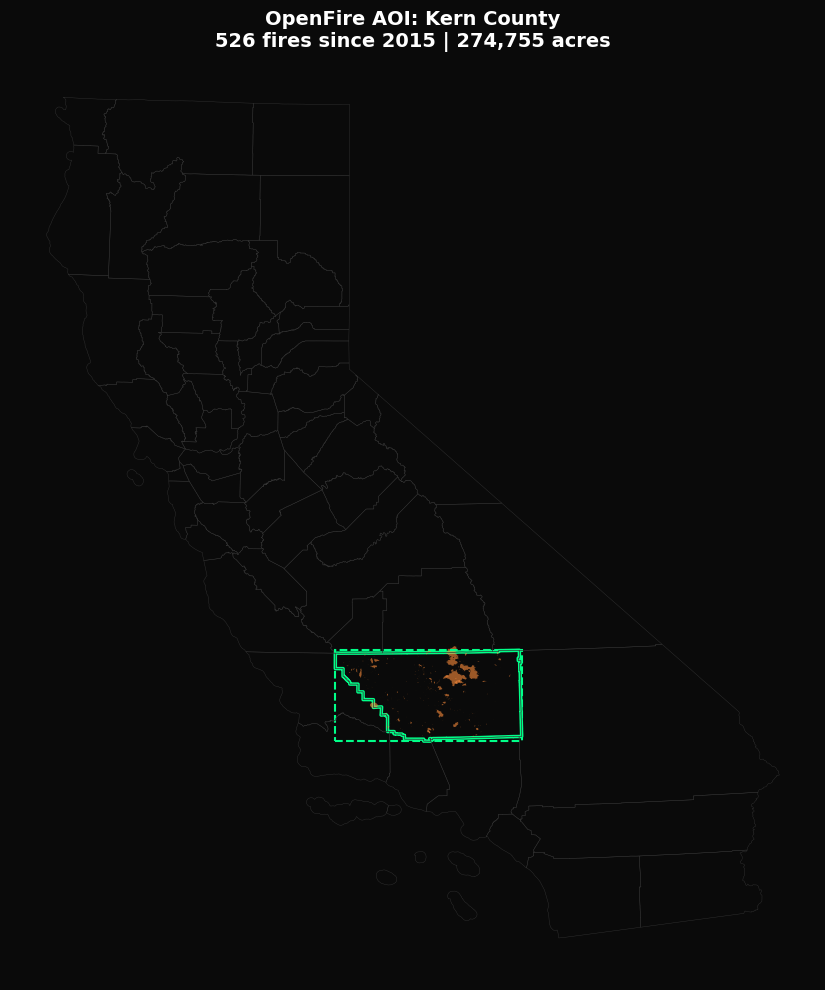


✓ AOI selected! Use the GEE coordinates from C9 in your Earth Engine scripts.


In [58]:
# C10: Final AOI map
fig, ax = plt.subplots(figsize=(12, 10))
ax.set_facecolor(BG_COLOR)

# All of California in dim
ca_counties.boundary.plot(ax=ax, color="#333333", linewidth=0.3)

# Highlight chosen county
aoi_counties.plot(ax=ax, color="none", edgecolor="#00ff88", linewidth=2.5)

# S2-era fires in the AOI
aoi_fires_s2.plot(ax=ax, color="#fd8d3c", alpha=0.6, linewidth=0)

# Bounding box in EPSG:3310
aoi_bbox_albers = aoi_counties.total_bounds
from matplotlib.patches import Rectangle
rect = Rectangle(
    (aoi_bbox_albers[0], aoi_bbox_albers[1]),
    aoi_bbox_albers[2] - aoi_bbox_albers[0],
    aoi_bbox_albers[3] - aoi_bbox_albers[1],
    linewidth=1.5, edgecolor="#00ff88", facecolor="none", linestyle="--",
)
ax.add_patch(rect)

ax.set_title(
    f"OpenFire AOI: {', '.join(CHOSEN_COUNTIES)} County\n"
    f"{len(aoi_fires_s2)} fires since 2015 | "
    f"{aoi_fires_s2['acres'].sum():,.0f} acres",
    fontsize=14, fontweight="bold", color="white",
)
ax.set_axis_off()

fig.patch.set_facecolor(BG_COLOR)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chosen_aoi.png", dpi=150, bbox_inches="tight", facecolor=BG_COLOR)
plt.show()

print(f"\n✓ AOI selected! Use the GEE coordinates from C9 in your Earth Engine scripts.")